# Ses İşleme

Bu canlı kodda hem ses dalgaları üretecek hem de diskteki `.wav` dosyalarını analiz edeceğiz.

Amacımız, tıpkı görsellerin veya videoların (ve genel olarak bir bilgisayarın işlediği hemen her şeyin) olduğu gibi, bir sesin sayılarla nasıl kodlandığını anlamak.

In [1]:
!pip install scipy --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.io import wavfile
from IPython.display import Audio

## Ses Sentezi

Bir sesi sıfırdan üretmeden önce, bilgisayarın mikrofondan gelen sesi nasıl kaydettiğine bakalım:

<img src="https://wagon-public-datasets.s3.amazonaws.com/03-Maths/01-Algebra-Calculus/mic_recording_original.png" width=1000>

In [3]:
R = 44100 # Sampling rate
D = 3     # Duration of the sound

❓ Frekans 
 (Hz cinsinden) alan ve örnekleme oranı R, süre D (sabitler) olacak şekilde sinüzoidal bir sinyal üreten note(f) fonksiyonunu yazın.

In [4]:
def note(f):
    t = np.arange(0, D * R) / R
    signal = np.sin(2 * np.pi * f * t)
    return signal

❓ `note(f)` çıktısını `440 Hz` için çizin. `1 Hz` için de çizin. Ne görüyorsunuz?

In [6]:
print(note(440))
print(note(1))

[ 0.          0.06264832  0.12505052 ... -0.18696144 -0.12505052
 -0.06264832]
[ 0.          0.00014248  0.00028495 ... -0.00042743 -0.00028495
 -0.00014248]


❓ `note` fonksiyonunu çağırarak akorttaki `A` notasını (440 Hz) üretin. Çalın.

<details>
    <summary>💡 <strong>İpucu</strong></summary>

Notebook’un ilk hücresinde içe aktarılmış `IPython.display` içindeki [`Audio`](https://ipython.org/ipython-doc/3/api/generated/IPython.display.html) nesnesini kullanın.
</details>

In [7]:
a440 = note(440)

Audio(a440, rate=R)

❓ Birden fazla notayı üst üste bindirmeyi deneyin; örneğin `A` + tam beşli, majör (veya minör) üçlü vb. Bunları `chord` değişkeninde toplayın. Çalın!

<details>
    <summary>💡 <strong>İpucu</strong></summary>
    
Wikipedia’daki [Frekans Oranı](https://en.wikipedia.org/wiki/Interval_(music)#Frequency_ratios) tablosuna bakın. Örneğin tam beşlinin oranı $\frac{3}{2}$’dir.
</details>

In [8]:
c_sharp = note(550)   # majör üçlü
e = note(660)         # tam beşli

chord = a440 + c_sharp + e

# ses seviyesini taşmaması için normalize edelim
chord = chord / np.max(np.abs(chord))

Audio(chord, rate=R)

❓ Akorun ilk `1000` örneğini çizin

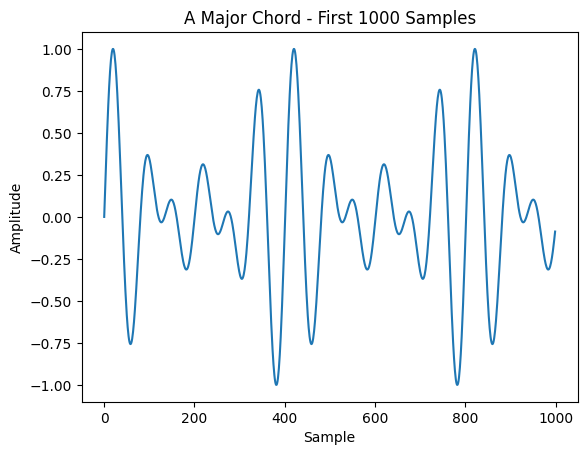

In [9]:
# ilk 1000 örnek
plt.plot(chord[:1000])
plt.title("A Major Chord - First 1000 Samples")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

## [Hızlı Fourier dönüşümü](https://en.wikipedia.org/wiki/Fast_Fourier_transform)

> Fourier analizi, bir sinyali özgün alanından (çoğunlukla zaman veya uzay) frekans alanındaki bir gösterime dönüştürür ve tersini de yapar.
> **Wikipedia**

<img src="https://wagon-public-datasets.s3.amazonaws.com/03-Maths/01-Algebra-Calculus/fourier_transformation.png" width=550>

Yukarıda oluşturduğumuz sinyalleri analiz etmek için [`scipy.fft`](https://docs.scipy.org/doc/scipy/tutorial/fft.html) kullanalım.

Aşağıdaki kodu çalıştırın. Yukarıdaki `chord` değişkenini değiştirip yeniden çizin. Ne görüyorsunuz?

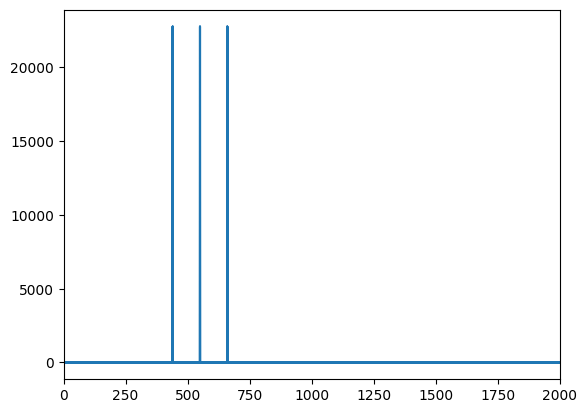

In [10]:
import scipy.fft

def plot_fft(signal, rate, freq_max):
    Y = np.abs(scipy.fft.fft(signal))
    X = np.abs(scipy.fft.fftfreq(Y.size) * rate)
    plt.xlim(0, freq_max)
    plt.plot(X, Y)

plot_fft(chord, R, 2000)

## Gerçek hayattan örnekler

Klasördeki `.wav` dosyalarına `fft` uygulayalım:

In [11]:
!ls -lh *.wav

-rw-r--r--  1 aybukealtuntas  staff   505K May  3 20:12 bird.wav
-rw-r--r--  1 aybukealtuntas  staff   379K May  3 20:12 blissful_bell.wav
-rw-r--r--  1 aybukealtuntas  staff   400K May  3 20:12 guitar_G.wav
-rw-r--r--  1 aybukealtuntas  staff   265K May  3 20:12 piano_F.wav
-rw-r--r--  1 aybukealtuntas  staff   100K May  3 20:12 snare_80s.wav


`bird.wav` dosyasındaki sesi yükleyelim ve sesin **dalga biçimini (waveform)** görselleştirelim

In [12]:
rate, audio = wavfile.read("bird.wav")
audio.T[0][R:(R+10)]

array([-396, -616, -699, -663, -531, -339, -138,   25,  126,  166],
      dtype=int16)

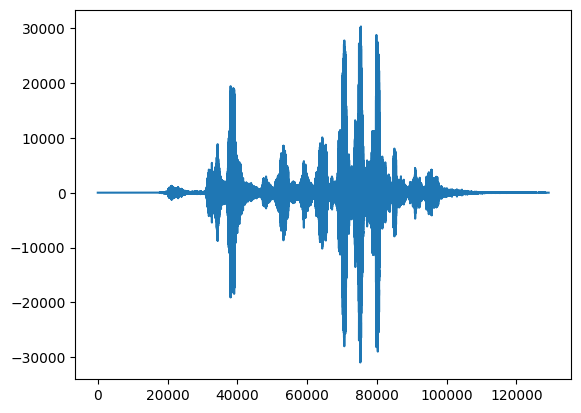

In [13]:
rate, audio = wavfile.read("bird.wav")
plt.plot(audio.T[0])

Şimdi bu sinyale FFT uygulayıp grafiğini çizelim ve sesi çalalım

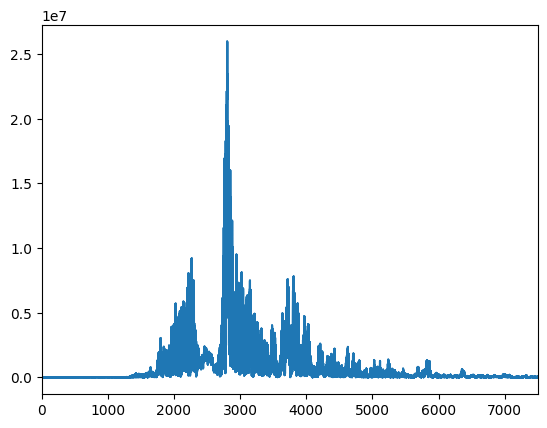

In [14]:
plot_fft(audio.T[0], rate, 7500)
Audio(audio.T[0], rate=rate)

---

Harika!

❓ Şimdi sıra sizde: diğer seslerle de aynı analizi yapmayı deneyin (yukarıdaki `!ls -lh *.wav` hücresine bakın).

In [15]:
rate, audio = wavfile.read("blissful_bell.wav")
audio.T[0][R:(R+10)]

array([ -896,  -950,  -999, -1024, -1036, -1032, -1007,  -977,  -934,
        -889], dtype=int16)

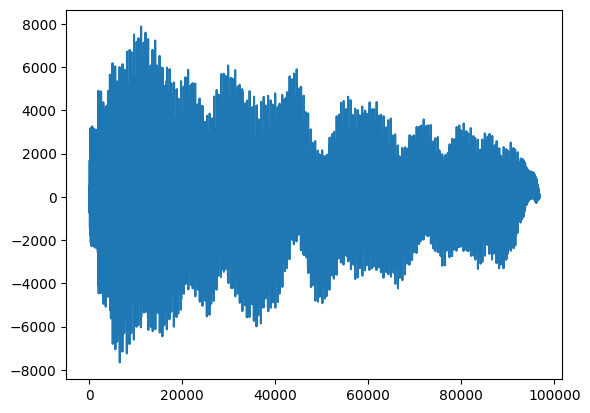

In [16]:
rate, audio = wavfile.read("blissful_bell.wav")
plt.plot(audio.T[0])

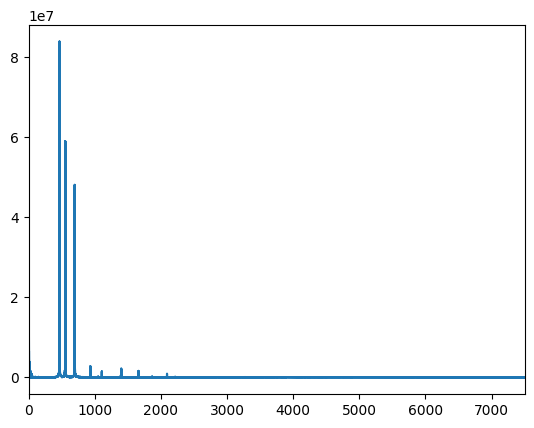

In [17]:
plot_fft(audio.T[0], rate, 7500)
Audio(audio.T[0], rate=rate)

In [18]:
def analyze_audio(path, start=0, n_samples=10, fft_limit=7500):
    # 1. dosyayı oku
    rate, audio = wavfile.read(path)

    # 2. stereo ise mono yap
    if audio.ndim > 1:
        audio = audio.mean(axis=1)

    # 3. seçilen segment
    segment = audio[start:start+n_samples]

    # 4. ham örnekleri yazdır
    print("İlk örnekler:", segment)

    # 5. waveform
    plt.figure(figsize=(10,3))
    plt.plot(audio)
    plt.title("Waveform")
    plt.show()

    # 6. FFT çizimi
    freqs = np.fft.rfftfreq(len(audio), d=1/rate)
    fft_vals = np.abs(np.fft.rfft(audio))

    plt.figure(figsize=(10,3))
    plt.plot(freqs[:fft_limit], fft_vals[:fft_limit])
    plt.title("FFT Spectrum")
    plt.show()

    # 7. ses oynat
    return Audio(audio, rate=rate), rate, audio

İlk örnekler: [  -976.5    232.     189.   -1233.   -3990.5  -7108.   -9710.  -11518.
 -12359.  -11985. ]


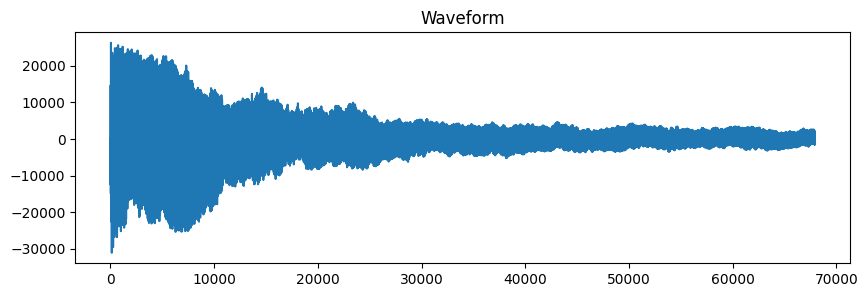

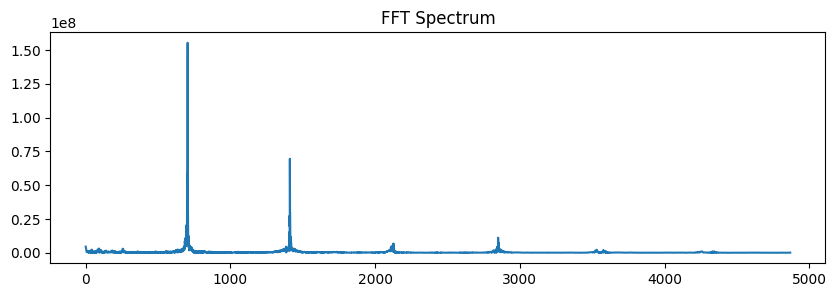

(<IPython.lib.display.Audio object>,
 44100,
 array([ -976.5,   232. ,   189. , ..., -1379.5, -1237. , -1060. ]))

In [20]:
analyze_audio("piano_F.wav",0,10,7500)